<a href="https://colab.research.google.com/github/Loki-33/Stuffs/blob/main/Grokiing_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
N=12
M=10
alpha=0.49

In [3]:
import numpy as np

In [4]:
def mod_add_table(N):
  return (np.arange(N).reshape(-1,1) + np.arange(N).reshape(1,-1))%N

In [5]:
full_table = mod_add_table(N)
print(full_table)

[[ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 1  2  3  4  5  6  7  8  9 10 11  0]
 [ 2  3  4  5  6  7  8  9 10 11  0  1]
 [ 3  4  5  6  7  8  9 10 11  0  1  2]
 [ 4  5  6  7  8  9 10 11  0  1  2  3]
 [ 5  6  7  8  9 10 11  0  1  2  3  4]
 [ 6  7  8  9 10 11  0  1  2  3  4  5]
 [ 7  8  9 10 11  0  1  2  3  4  5  6]
 [ 8  9 10 11  0  1  2  3  4  5  6  7]
 [ 9 10 11  0  1  2  3  4  5  6  7  8]
 [10 11  0  1  2  3  4  5  6  7  8  9]
 [11  0  1  2  3  4  5  6  7  8  9 10]]


In [6]:
pairs_and_sum = np.array([(x1,x2,full_table[x1,x2]) for x1 in range(N) for x2 in range(N)])

In [7]:
pairs_and_sum

array([[ 0,  0,  0],
       [ 0,  1,  1],
       [ 0,  2,  2],
       [ 0,  3,  3],
       [ 0,  4,  4],
       [ 0,  5,  5],
       [ 0,  6,  6],
       [ 0,  7,  7],
       [ 0,  8,  8],
       [ 0,  9,  9],
       [ 0, 10, 10],
       [ 0, 11, 11],
       [ 1,  0,  1],
       [ 1,  1,  2],
       [ 1,  2,  3],
       [ 1,  3,  4],
       [ 1,  4,  5],
       [ 1,  5,  6],
       [ 1,  6,  7],
       [ 1,  7,  8],
       [ 1,  8,  9],
       [ 1,  9, 10],
       [ 1, 10, 11],
       [ 1, 11,  0],
       [ 2,  0,  2],
       [ 2,  1,  3],
       [ 2,  2,  4],
       [ 2,  3,  5],
       [ 2,  4,  6],
       [ 2,  5,  7],
       [ 2,  6,  8],
       [ 2,  7,  9],
       [ 2,  8, 10],
       [ 2,  9, 11],
       [ 2, 10,  0],
       [ 2, 11,  1],
       [ 3,  0,  3],
       [ 3,  1,  4],
       [ 3,  2,  5],
       [ 3,  3,  6],
       [ 3,  4,  7],
       [ 3,  5,  8],
       [ 3,  6,  9],
       [ 3,  7, 10],
       [ 3,  8, 11],
       [ 3,  9,  0],
       [ 3, 10,  1],
       [ 3, 1

In [8]:
np.random.shuffle(pairs_and_sum)
train_set = pairs_and_sum[:int(alpha*len(pairs_and_sum))]
test_set = pairs_and_sum[int(alpha*len(pairs_and_sum)):]

In [9]:
import torch.nn.functional as F

In [11]:
def one_hot_encode(dataset, N):
  inputs = dataset[:, :2]
  targets = dataset[:,2]

  inputs_one_hot = F.one_hot(inputs, num_classes=N).float()
  targets_one_hot = F.one_hot(targets, num_classes=N).float()

  inputs_one_hot = inputs_one_hot.view(-1, 2*N)
  return inputs_one_hot, targets_one_hot

In [12]:
train_inputs_one_hot, train_targets_one_hot = one_hot_encode(torch.from_numpy(train_set).long(), N)
test_inputs_one_hot, test_targets_one_hot = one_hot_encode(torch.from_numpy(test_set).long(), N)

In [13]:
for i in range(3):
    print(train_set[i])
    print(train_inputs_one_hot[i,:N])
    print(train_inputs_one_hot[i,N:])
    print(train_targets_one_hot[i,:])

[11  7  6]
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
[10  0 10]
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
[ 6 11  5]
tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])


In [14]:
import torch.nn as nn

In [16]:
class GrokNet(nn.Module):
  def __init__(self, N, M):
    super(GrokNet, self).__init__()
    self.N = torch.tensor(N, dtype=torch.float32)
    self.M = torch.tensor(M, dtype=torch.float32)
    self.W1 = nn.Parameter(torch.randn(2*N, M))
    self.W2 = nn.Parameter(torch.randn(M, N))

  def forward(self, x):
    z = torch.square(x @ self.W1 / torch.sqrt(self.M))
    y = (z @ self.W2)/self.N
    return y
  def hidden(self, x):
    with torch.no_grad():
      return torch.square(x@self.W1/torch.sqrt(self.M))

In [17]:
from tqdm import trange
import torch.optim as optim
import matplotlib.pyplot as plt

In [18]:
device = 'cuda'

In [19]:
def generate_dataset(N, alpha):
    full_set = (np.arange(N).reshape(-1,1) + np.arange(N).reshape(1,-1)) % N
    pairs_and_sums = np.array([(x1, x2, full_set[x1, x2]) for x1 in range(N) for x2 in range(N)])

    np.random.shuffle(pairs_and_sums)
    train_set = pairs_and_sums[:int(alpha * len(pairs_and_sums))]
    test_set = pairs_and_sums[int(alpha * len(pairs_and_sums)):]

    def one_hot_encode(dataset, N):
        inputs = dataset[:, :2]
        targets = dataset[:, 2]

        # Convert inputs and targets to one-hot vectors
        inputs_one_hot = F.one_hot(inputs, num_classes=N).float()
        targets_one_hot = F.one_hot(targets, num_classes=N).float()

        # Reshape inputs from [dataset_size, 2, N] to [dataset_size, 2*N]
        inputs_one_hot = inputs_one_hot.view(-1, 2*N)

        return inputs_one_hot, targets_one_hot

    train_inputs_one_hot, train_targets_one_hot = one_hot_encode(torch.from_numpy(train_set).long(), N)
    test_inputs_one_hot, test_targets_one_hot = one_hot_encode(torch.from_numpy(test_set).long(), N)

    return train_inputs_one_hot, train_targets_one_hot, test_inputs_one_hot, test_targets_one_hot

In [21]:
N, M = 40, 120
alpha=0.4
train_inputs_one_hot, train_targets_one_hot, test_inputs_one_hot, test_targets_one_hot = generate_dataset(N, alpha)
model = GrokNet(N, M).to(device)
model.to(device)
train_inputs_one_hot = train_inputs_one_hot.to(device)
train_targets_one_hot = train_targets_one_hot.to(device)
test_inputs_one_hot = test_inputs_one_hot.to(device)
test_targets_one_hot = test_targets_one_hot.to(device)

optimizer = optim.AdamW(model.parameters())
criterion = nn.MSELoss()

In [22]:
epochs = 20000
train_losses = np.zeros(epochs)
test_losses = np.zeros(epochs)
train_accuracies = np.zeros(epochs)
test_accuracies = np.zeros(epochs)

In [23]:
progress_bar = trange(epochs)
for epoch in progress_bar:
    ouputs = model(train_inputs_one_hot)
    loss = criterion(ouputs, train_targets_one_hot)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses[epoch] = loss.item()
    train_acc = (ouputs.argmax(dim=1) == train_targets_one_hot.argmax(dim=1)).float().mean().item()
    train_accuracies[epoch] = train_acc

    with torch.no_grad():
      test_outputs = model(test_inputs_one_hot)
      test_loss = criterion(test_outputs, test_targets_one_hot)
      test_losses[epoch] = test_loss.item()
      test_acc = (test_outputs.argmax(dim=1) == test_targets_one_hot.argmax(dim=1)).float().mean().item()
      test_accuracies[epoch] = test_acc

    progress_bar.set_postfix({"train accuracy": f"{train_acc:.4f}", "test accuracy": f"{test_acc:.4f}"})

100%|██████████| 20000/20000 [01:07<00:00, 294.70it/s, train accuracy=1.0000, test accuracy=1.0000]


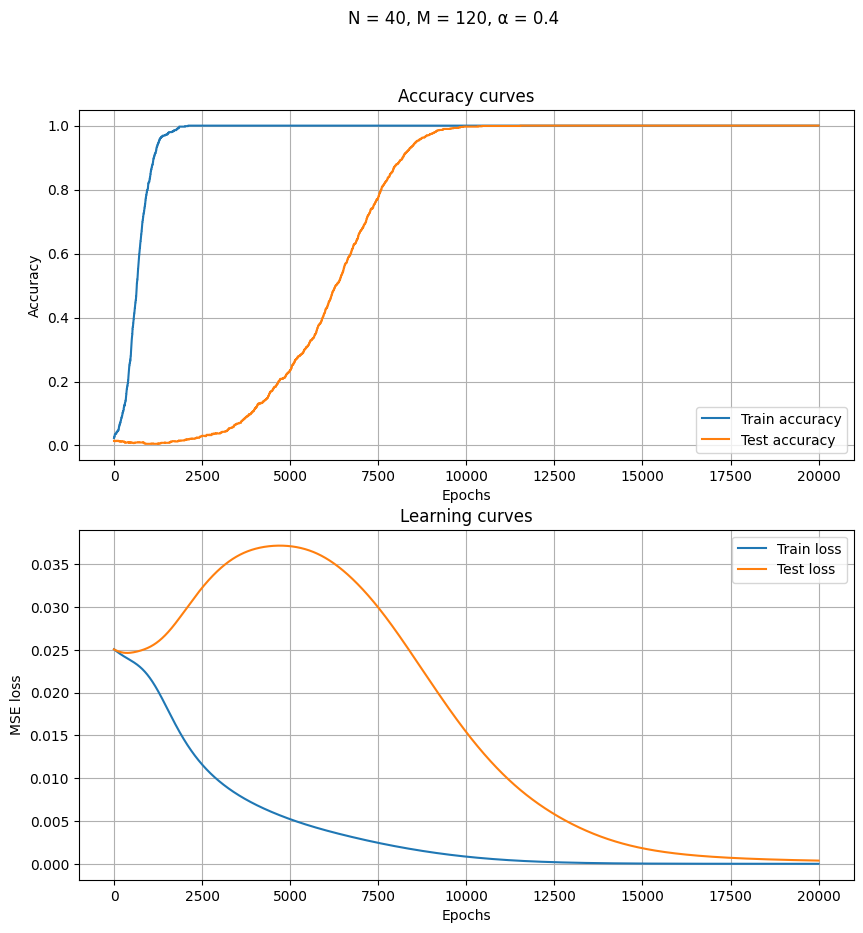

In [26]:
fig, ax = plt.subplots(2,1,figsize=(10, 10))


ax[0].plot(train_accuracies, label="Train accuracy")
ax[0].plot(test_accuracies, label="Test accuracy")
ax[0].set(title=f'Accuracy curves', xlabel='Epochs', ylabel='Accuracy')
ax[0].legend()
ax[0].grid()

ax[1].plot(train_losses, label="Train loss")
ax[1].plot(test_losses, label="Test loss")
ax[1].set(title=f'Learning curves', xlabel='Epochs', ylabel='MSE loss')
ax[1].legend()
ax[1].grid()

fig.suptitle(f"N = {N}, M = {M}, α = {alpha}")
plt.show()


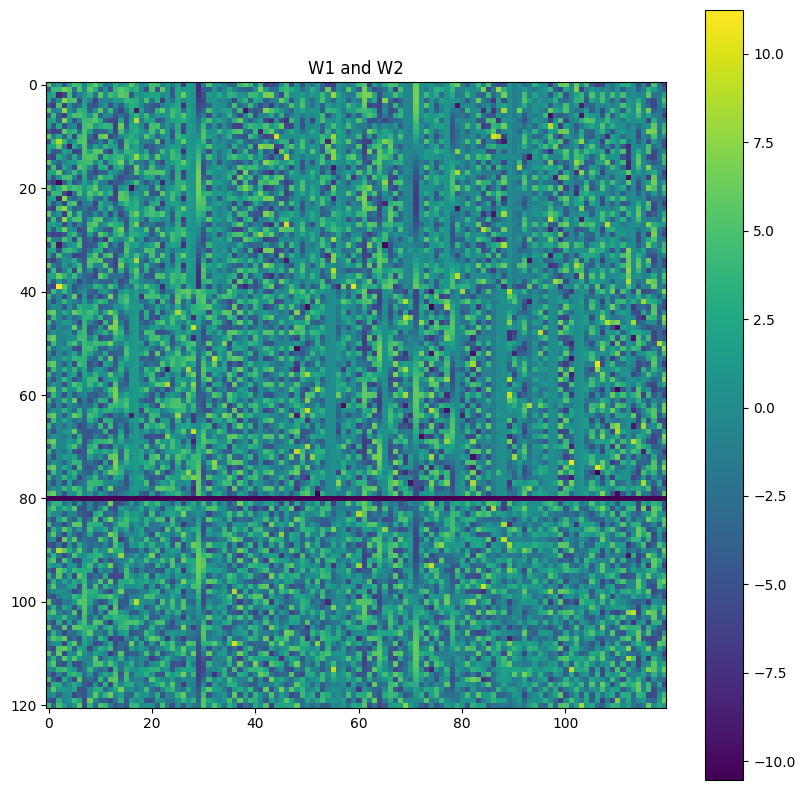

In [27]:
def visualize_network(W1, W2, title):
    # Find minimal value for the separator
    min_val = min(W1.min(), W2.min())

    separator = np.full((1, W1.shape[1]), min_val)

    # Stack everything together
    W = np.concatenate((W1, separator, W2), axis=0)

    # Now you can use plt.imshow to visualize the stacked matrices
    plt.figure(figsize=(10, 10))
    cax = plt.imshow(W, cmap='viridis')
    plt.colorbar(cax)
    plt.title(title)
    plt.show()

W1 = model.W1.detach().cpu().numpy()
W2 = model.W2.T.detach().cpu().numpy()
visualize_network(W1, W2, 'W1 and W2')

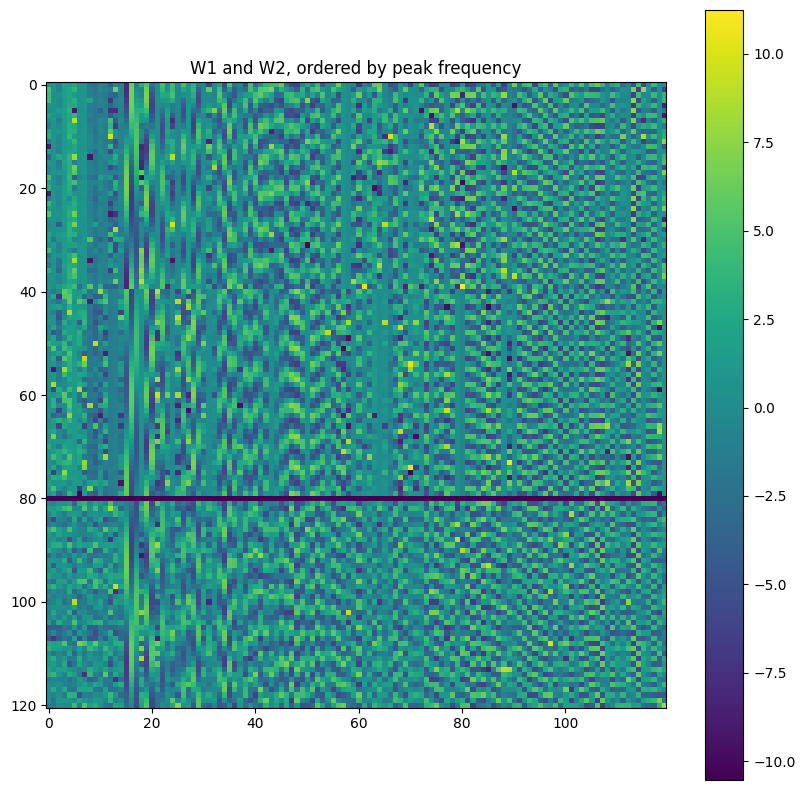

In [28]:
from scipy.fftpack import fft

def get_fft_order(W1, W2):
    # Compute power spectrum for each column in W1 (split to two) and W2
    power_spectrums = np.abs(fft(W1[:N,:], axis=0))**2
    power_spectrums += np.abs(fft(W1[N:,:], axis=0))**2
    power_spectrums += np.abs(fft(W2, axis=0))**2

    # Find the peak frequency for each column
    peak_freqs = np.argmax(power_spectrums, axis=0)

    # Get the order of indices that would sort the peak frequencies
    order = np.argsort(peak_freqs)
    return order

def visualize_network_fft(W1, W2):
    order = get_fft_order(W1, W2)
    W1_ordered = W1[:, order]
    W2_ordered = W2[:, order]

    visualize_network(W1_ordered, W2_ordered, 'W1 and W2, ordered by peak frequency')

visualize_network_fft(W1, W2)

/tmp/ipython-input-887829805.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  z = combined @ W1 / np.sqrt(model.M)


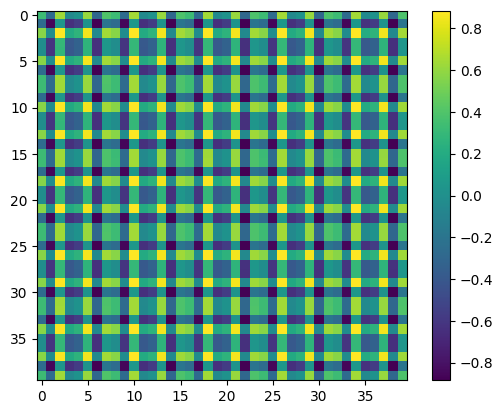

In [29]:
import numpy as np
import torch

def pre_activation_mapping(N, k, W1):
    activations = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            one_hot_i = F.one_hot(torch.tensor(i), num_classes=N).float().view(1,-1)
            one_hot_j = F.one_hot(torch.tensor(j), num_classes=N).float().view(1,-1)
            combined = torch.cat([one_hot_i, one_hot_j], dim=1)
            z = combined @ W1 / np.sqrt(model.M)
            activations[i, j] = z[0, k].item()
    return activations

activations = pre_activation_mapping(40, 10, W1)
plt.imshow(activations, cmap='viridis')
plt.colorbar()
plt.show()

In [30]:
def generate_activation_plot(N, W1, order):
    margin = 3
    N1, N2 = 10, 10
    full_array = np.full(((N + margin) * N1, (N + margin) * N2), -0.6)

    for n in trange(N1 * N2):
        n1, n2 = n // N2, n % N2
        k = order[N1 * n1 + n2]
        activations = pre_activation_mapping(N, k, W1)
        full_array[n1 * (N + margin): n1 * (N + margin) + N, n2 * (N + margin): n2 * (N + margin) + N] = activations
    plt.figure(figsize=(20,20))
    plt.imshow(full_array, cmap='viridis')
    plt.axis('off')
    plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipython-input-887829805.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  z = combined @ W1 / np.sqrt(model.M)
100%|██████████| 100/100 [00:26<00:00,  3.71it/s]


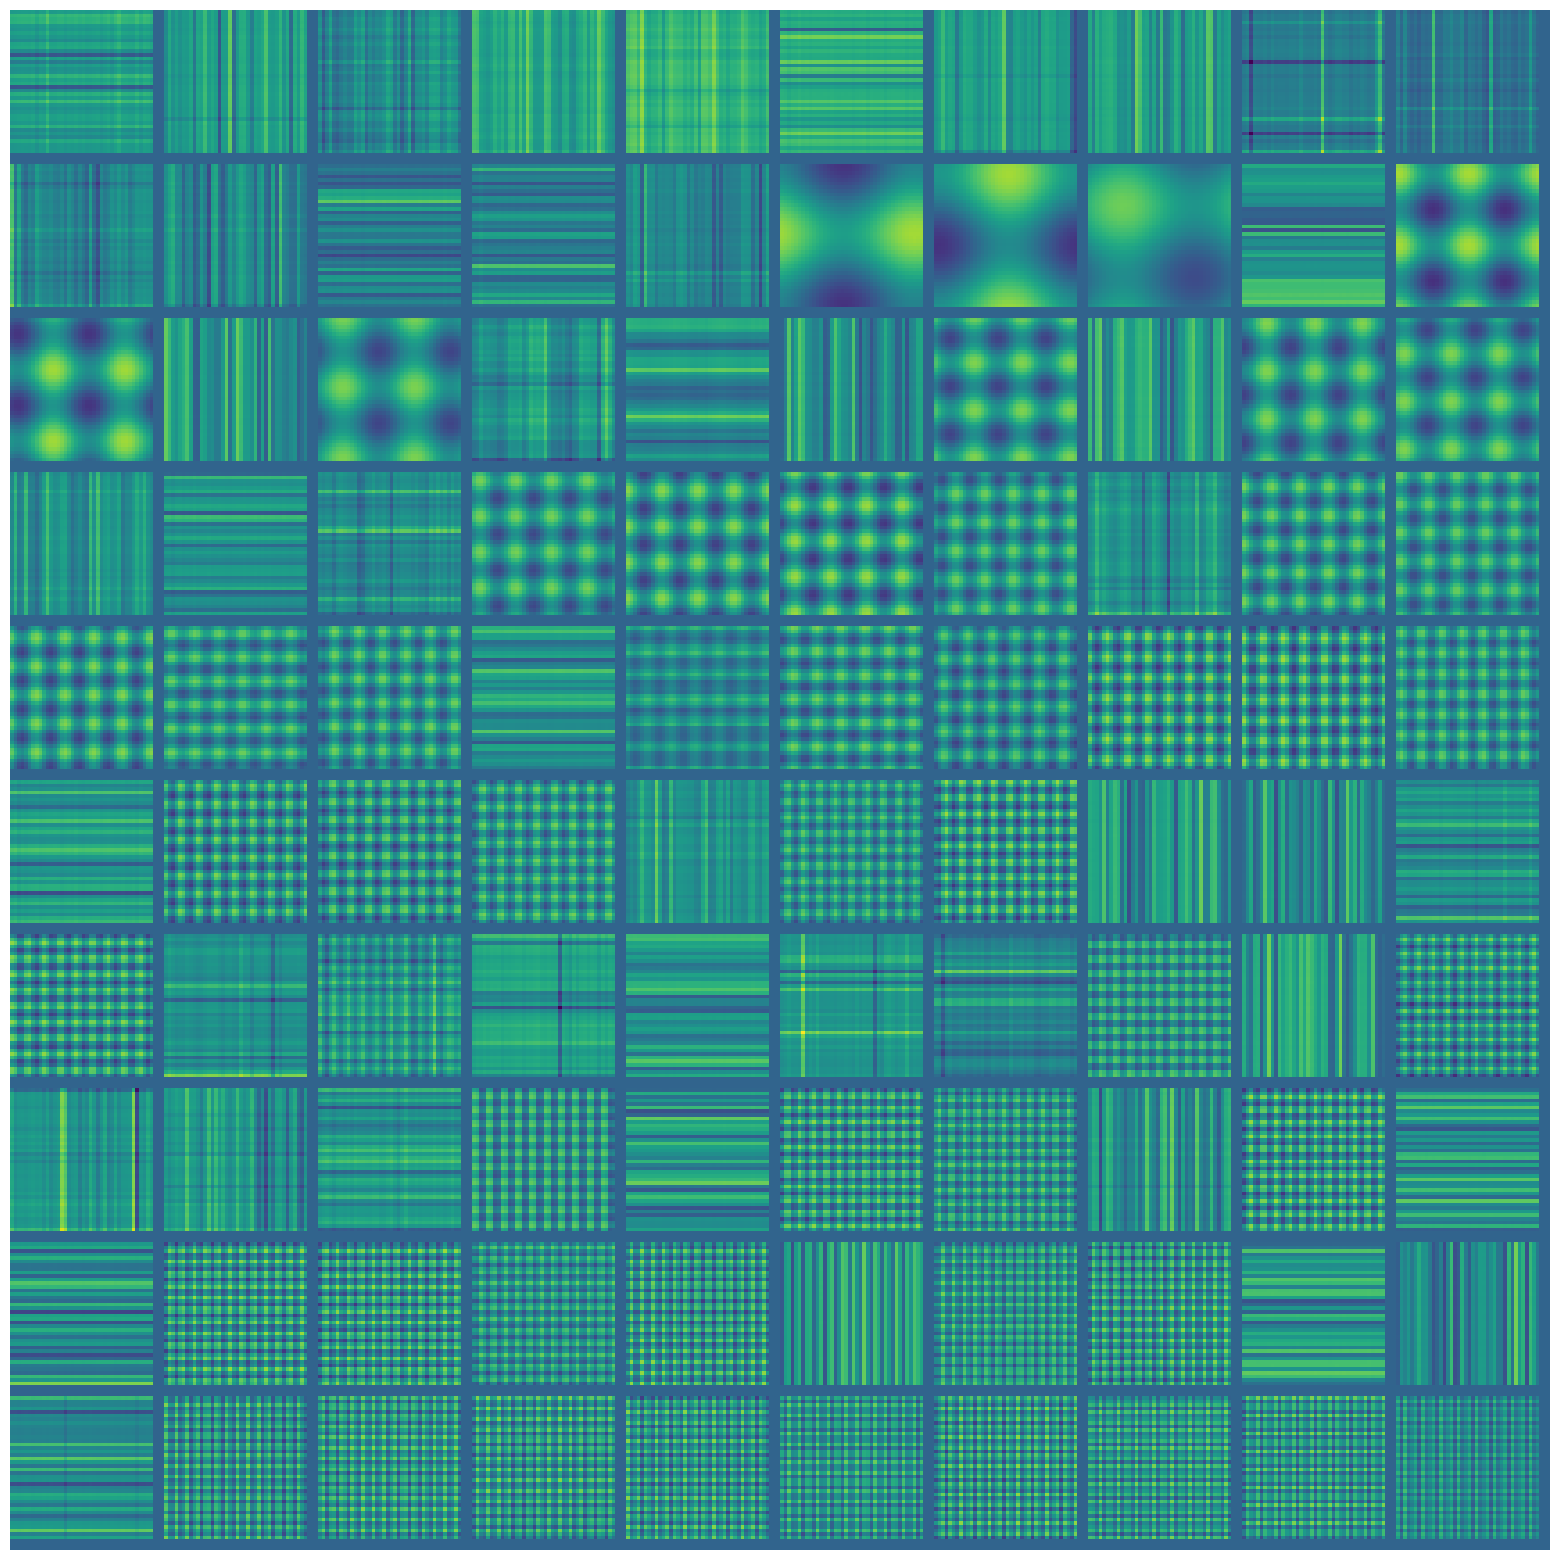

In [31]:
order = get_fft_order(W1, W2)
generate_activation_plot(40, W1, order)

In [35]:
np.full(((N + 3) * 10, (N + 3) * 10), -0.6).shape

(430, 430)